In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plotData(X,y):
    plt.figure
    plt.plot(X[np.where(y==1),0],X[np.where(y==1),1],'k+',linewidth = 2,markersize=7)
    plt.plot(X[np.where(y==0),0],X[np.where(y==0),1],'ko',markerfacecolor = 'y',markersize=7)
    plt.xlabel('Exam 1 score')
    plt.ylabel('Exam 2 score')
    plt.legend('Admitted', 'Not admitted')
    plt.show()

In [3]:
def sigmoid(z):
    g = np.zeros(z.shape)
    g = 1/(1+np.exp(-z))
    return g

In [4]:
def costFunction(theta,X,y):
    m = len(y)
    J = 0
    grad = np.zeros(theta.shape)
    h = sigmoid(X@theta)
    #print(theta)
    #plt.figure()
    #plt.scatter(range(0,100),h)
    J = 1/m*(-y.T@np.log(h)-(1-y).T@np.log(1-h))
    grad[0] = 1/m*(X[:,0].reshape(1,m)@(h-y))
    grad[1:] = 1/m*(X[:,1:].T@(h-y))
    return J, grad

In [5]:
def mapFeature(X1,X2):
    degree = 6
    out = np.ones((len(X1),1))
    for i in np.arange(1,degree+1):
        for j in np.arange(0,i+1):
            out = np.concatenate((out, X1**(i-j)*(X2**j)),axis=1)
    return out

In [6]:
def plotDecisionBoundary(X,y,theta):
    m,n = X.shape
    if n <= 3:
        plot_x = np.array([np.min(X[:,1])-2, np.max(X[:,1])+2])
        plot_y = -1/theta[2]*(theta[1]*plot_x+theta[0])
        plt.figure(2)
        plt.plot(plot_x,plot_y,'b-',linewidth=2) 
    else: 
        u = np.linspace(-1,1.5,50)
        v = np.linspace(-1,1.5,50)
        z = np.zeros((len(u),len(v)))
        for i in np.arange(len(u)):
            for j in np.arange(len(v)):
                z[i,j] =float(mapFeature(np.array([u[i]],ndmin=2),np.array([v[j]],ndmin=2))@theta.reshape(n,1))
        z = z.T
        plt.figure
        plt.plot(X[np.where(y==1),1],X[np.where(y==1),2],'k+',linewidth = 2,markersize=7)
        plt.plot(X[np.where(y==0),1],X[np.where(y==0),2],'ko',markerfacecolor = 'y',markersize=7)
        plt.xlabel('Chip 1')
        plt.ylabel('Chip 2')
        plt.legend('Selected', 'Not selected')  
        plt.contour(u,v,z,levels = [0])
        plt.axis([-1,1.3,-1,1.3])

In [7]:
df = pd.read_csv('ex2data2.csv')
df.head()

,x1,x2,y
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


C:\Users\thein\AppData\Local\Temp\ipykernel_30628\2095019850.py:7: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Admitted', 'Not admitted')


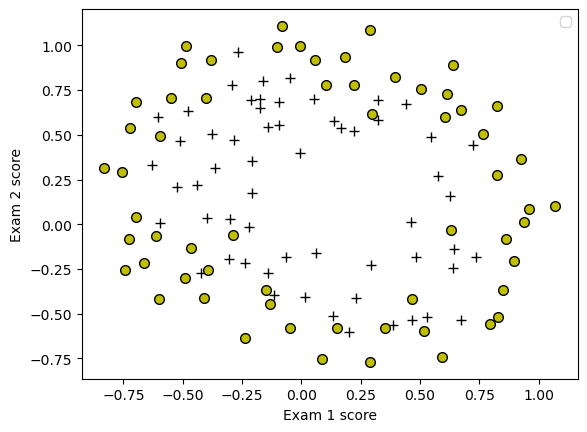

In [8]:
X= np.array(df[["x1","x2"]].values)
y = (df["y"].values).reshape(-1).T
plotData(X[:,0:2],y)

In [9]:
m = X.shape[0]
X = mapFeature(X[:,0].reshape(m,1),X[:,1].reshape(m,1))

In [17]:
X.shape

(118, 28)

In [18]:
m,n = X.shape
theta_ini = np.zeros((n))

cost,grad = costFunction(theta_ini, X, y)
cost, grad

C:\Users\thein\AppData\Local\Temp\ipykernel_30628\898703798.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0] = 1/m*(X[:,0].reshape(1,m)@(h-y))


(0.6931471805599453,
 array([8.47457627e-03, 1.87880932e-02, 7.77711864e-05, 5.03446395e-02,
        1.15013308e-02, 3.76648474e-02, 1.83559872e-02, 7.32393391e-03,
        8.19244468e-03, 2.34764889e-02, 3.93486234e-02, 2.23923907e-03,
        1.28600503e-02, 3.09593720e-03, 3.93028171e-02, 1.99707467e-02,
        4.32983232e-03, 3.38643902e-03, 5.83822078e-03, 4.47629067e-03,
        3.10079849e-02, 3.10312442e-02, 1.09740238e-03, 6.31570797e-03,
        4.08503006e-04, 7.26504316e-03, 1.37646175e-03, 3.87936363e-02]))

In [11]:
err = 1
tol = 1e-6
alpha = 0.004
h = np.zeros((m,1))
ii = 1
J = []
while err > tol:
    cost, grad = costFunction(theta_ini,X,y)
    J.append(cost)
    theta_new=theta_ini-alpha*grad
    err = np.max(np.abs(theta_ini-theta_new))
    # print(err)
    ii += 1
    # index =np.ix_([-1],np.arange(0,7))
    # theta_old = np.transpose(theta_new[index])
    theta_ini = theta_new

C:\Users\thein\AppData\Local\Temp\ipykernel_30628\898703798.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0] = 1/m*(X[:,0].reshape(1,m)@(h-y))


In [ ]:
plt.plot(range(ii-1),J)

In [12]:
print('Solution converges after {} iterations. \n'.format(ii))
print(theta_new)

Solution converges after 5234558 iterations. 

[ 4.13174406  1.68243308  5.4329443  -6.23550907 -8.62732452 -5.9878155
  3.22295099  1.34259544  5.32390481 -4.11365184 -3.36023511  4.65090411
 -5.18731467 -2.10094094 -9.433261   -2.46582073 -1.43532686  9.06996512
 -5.51101636 -7.05663168  5.55549323 -7.3590035  -0.05138194 -0.71803052
  5.57212024 -7.37773317 -5.76676578  0.99934805]


C:\Users\thein\AppData\Local\Temp\ipykernel_30628\4085618866.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i,j] =float(mapFeature(np.array([u[i]],ndmin=2),np.array([v[j]],ndmin=2))@theta.reshape(n,1))
C:\Users\thein\AppData\Local\Temp\ipykernel_30628\4085618866.py:21: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Selected', 'Not selected')


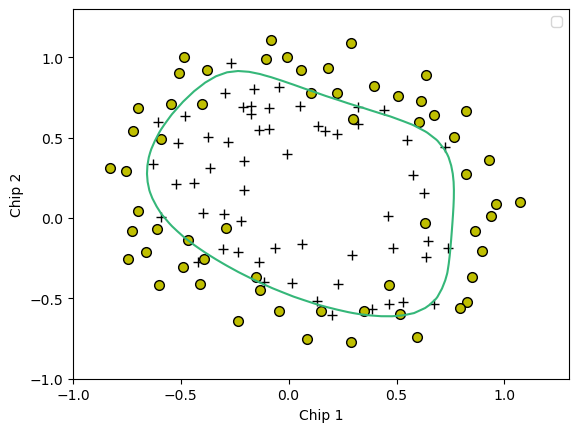

In [13]:
plotDecisionBoundary(X, y, theta_new)

In [14]:
def confusion_matrix(y_true, y_pred):
    # Initialize variables for true positive, true negative, false positive, and false negative
    tp = np.sum((np.array(y_pred) == 1) & (np.array(y_true) == 1))
    tn = np.sum((np.array(y_pred) == 0) & (np.array(y_true) == 0))
    fp = np.sum((np.array(y_pred) == 1) & (np.array(y_true) == 0))
    fn = np.sum((np.array(y_pred) == 0) & (np.array(y_true) == 1))
     # Print confusion matrix
    print("Confusion Matrix:")
    print(f"\t\t\t\t\t| Actual False \t| Actual True")
    print(f"Prediction False\t|     {tn}        |      {fn}")
    print(f"Prediction True\t\t|     {fp}         |      {tp}")
    return (tp,tn,fp,fn)

In [15]:
def f1Score(perVars):
    (tp,tn,fp,fn) = perVars
    # Compute precision, recall, and F1 score
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Print F1 score
    print(f"\nF1 Score: {f1:.2f}")
    return (f1,precision,recall)
    # Compute precision, recall, and F1 score

In [19]:
prediction = sigmoid(X@theta_new)
prediction[np.where(prediction>0.5)] = 1
prediction[np.where(prediction<0.5)] = 0
pervars = confusion_matrix(y, prediction)
F1,Precision,Recall = f1Score(pervars)
F1, Precision, Recall

Confusion Matrix:
					| Actual False 	| Actual True
Prediction False	|     49        |      8
Prediction True		|     11         |      50

F1 Score: 0.84


(0.8403361344537814, 0.819672131147541, 0.8620689655172413)